# APPLE PRICES DATASET-

In [2]:
import numpy as np 
import pandas as pd

## 1. Load Data.

In [3]:
df = pd.read_csv("apple_prices_dataset.csv")

## 2. Check Component.

In [4]:
df.head()

,Record_ID,Date,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
0,1,2024-11-27,Brazil,Gala,Premium,Supermarket,4.31,858,3697.98
1,2,2025-01-09,Japan,Fuji,Premium,Supermarket,2.96,1913,5662.48
2,3,2025-03-20,Canada,Red Delicious,Standard,Supermarket,2.35,542,1273.70
3,4,2025-08-02,Brazil,Golden Delicious,Economy,Supermarket,1.26,507,638.82
4,5,2025-08-13,Germany,Gala,Economy,Wholesale Market,2.97,151,448.47


In [5]:
df.tail()

,Record_ID,Date,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
495,496,2024-04-01,China,Granny Smith,Premium,Wholesale Market,4.42,1792,7920.64
496,497,2025-01-16,Australia,Pink Lady,Economy,Online Store,0.81,1772,1435.32
497,498,2024-05-26,USA,Red Delicious,Economy,Online Store,1.85,1405,2599.25
498,499,2024-12-12,Brazil,Pink Lady,Premium,Wholesale Market,1.03,68,70.04
499,500,2025-01-22,UAE,Red Delicious,Economy,Local Market,1.89,957,1808.73


In [6]:
df.shape

(500, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         500 non-null    int64  
 1   Date              500 non-null    str    
 2   Country           500 non-null    str    
 3   Apple_Variety     500 non-null    str    
 4   Quality_Grade     500 non-null    str    
 5   Market_Type       500 non-null    str    
 6   Price_per_KG_USD  500 non-null    float64
 7   Quantity_Sold_KG  500 non-null    int64  
 8   Revenue_USD       500 non-null    float64
dtypes: float64(2), int64(2), str(5)
memory usage: 35.3 KB


In [8]:
df.describe()

,Record_ID,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2.674440,1020.458000,2661.852900
std,144.481833,1.069996,578.570393,1887.389644
min,1.000000,0.810000,50.000000,49.500000
25%,125.750000,1.740000,511.250000,1165.857500
50%,250.500000,2.685000,1044.000000,2330.265000
75%,375.250000,3.602500,1534.250000,3840.607500
max,500.000000,4.490000,1999.000000,8461.560000


In [9]:
df.columns

Index(['Record_ID', 'Date', 'Country', 'Apple_Variety', 'Quality_Grade',
       'Market_Type', 'Price_per_KG_USD', 'Quantity_Sold_KG', 'Revenue_USD'],
      dtype='str')

## 3. Check NULL values and handle it.

In [10]:
df.isnull().sum()

Record_ID           0
Date                0
Country             0
Apple_Variety       0
Quality_Grade       0
Market_Type         0
Price_per_KG_USD    0
Quantity_Sold_KG    0
Revenue_USD         0
dtype: int64

## 4. Check DUPLICATES values and handle it.

In [11]:
df.duplicated().sum()

np.int64(0)

## 5. To check varieties of Data present in columns.

In [12]:
df['Country'].unique()

<StringArray>
[      'Brazil',        'Japan',       'Canada',      'Germany',
        'China',    'Australia',        'Italy',          'USA',
       'France',           'UK', 'Saudi Arabia',          'UAE',
        'India']
Length: 13, dtype: str

In [13]:
df['Apple_Variety'].unique()

<StringArray>
[            'Gala',             'Fuji',    'Red Delicious',
 'Golden Delicious',       'Honeycrisp',     'Granny Smith',
        'Pink Lady']
Length: 7, dtype: str

In [14]:
df['Quality_Grade'].unique()

<StringArray>
['Premium', 'Standard', 'Economy']
Length: 3, dtype: str

In [15]:
df['Market_Type'].unique()

<StringArray>
['Supermarket', 'Wholesale Market', 'Online Store', 'Local Market']
Length: 4, dtype: str

In [16]:
df['Apple_Variety'].value_counts()

Apple_Variety
Honeycrisp          78
Gala                77
Fuji                76
Pink Lady           73
Granny Smith        71
Red Delicious       67
Golden Delicious    58
Name: count, dtype: int64

In [17]:
df['Market_Type'].value_counts()

Market_Type
Supermarket         143
Wholesale Market    132
Local Market        130
Online Store         95
Name: count, dtype: int64

## 6. Date & Columns formatting.

### (i) Data -

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

### (ii) Columns -

In [19]:
df.columns = df.columns.str.lower() ## snake_case format.

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   record_id         500 non-null    int64         
 1   date              500 non-null    datetime64[us]
 2   country           500 non-null    str           
 3   apple_variety     500 non-null    str           
 4   quality_grade     500 non-null    str           
 5   market_type       500 non-null    str           
 6   price_per_kg_usd  500 non-null    float64       
 7   quantity_sold_kg  500 non-null    int64         
 8   revenue_usd       500 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 35.3 KB


## 7. To check Revenue_USD show correct revenue or not.

In [21]:
df['calculated_revenue'] = df['price_per_kg_usd'] * df['quantity_sold_kg']
df[['revenue_usd','calculated_revenue']].head()
# (df['revenue_usd'] == df['calculated_revenue']).all()
(df['revenue_usd'].round(2) == df['calculated_revenue'].round(2)).all()

np.True_

In [22]:
# df.drop('calculated_revenue' , axis=1 , inplace=True)

## 8. Date columns breaks with new sub-columns and Adjust Columns.

In [23]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

In [24]:
df.drop(['date' , 'month'] , axis=1 , inplace=True)

In [25]:
cols = list(df.columns)
cols.insert(5, cols.pop(cols.index('month_name')))
df = df[cols]

In [26]:
cols = list(df.columns)
cols.insert(6, cols.pop(cols.index('year')))
df = df[cols]

In [27]:
df.head(5)

,record_id,country,apple_variety,quality_grade,market_type,month_name,year,price_per_kg_usd,quantity_sold_kg,revenue_usd,calculated_revenue
0,1,Brazil,Gala,Premium,Supermarket,November,2024,4.31,858,3697.98,3697.98
1,2,Japan,Fuji,Premium,Supermarket,January,2025,2.96,1913,5662.48,5662.48
2,3,Canada,Red Delicious,Standard,Supermarket,March,2025,2.35,542,1273.70,1273.70
3,4,Brazil,Golden Delicious,Economy,Supermarket,August,2025,1.26,507,638.82,638.82
4,5,Germany,Gala,Economy,Wholesale Market,August,2025,2.97,151,448.47,448.47


In [28]:
df.describe()

,record_id,year,price_per_kg_usd,quantity_sold_kg,revenue_usd,calculated_revenue
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2024.508000,2.674440,1020.458000,2661.852900,2661.852900
std,144.481833,0.500437,1.069996,578.570393,1887.389644,1887.389644
min,1.000000,2024.000000,0.810000,50.000000,49.500000,49.500000
25%,125.750000,2024.000000,1.740000,511.250000,1165.857500,1165.857500
50%,250.500000,2025.000000,2.685000,1044.000000,2330.265000,2330.265000
75%,375.250000,2025.000000,3.602500,1534.250000,3840.607500,3840.607500
max,500.000000,2025.000000,4.490000,1999.000000,8461.560000,8461.560000


## 9. To handle OUTLIERS.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

### Boxplot Method -

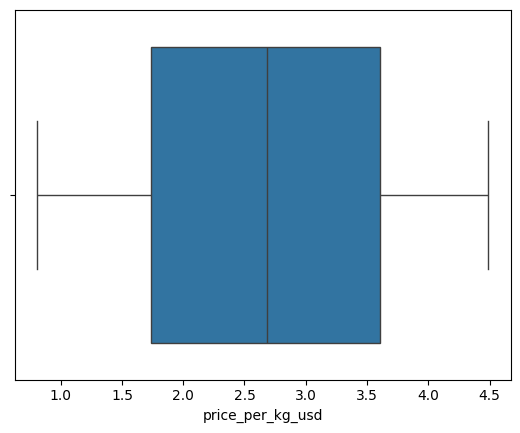

In [30]:
sns.boxplot(x=df['price_per_kg_usd'])
plt.show()

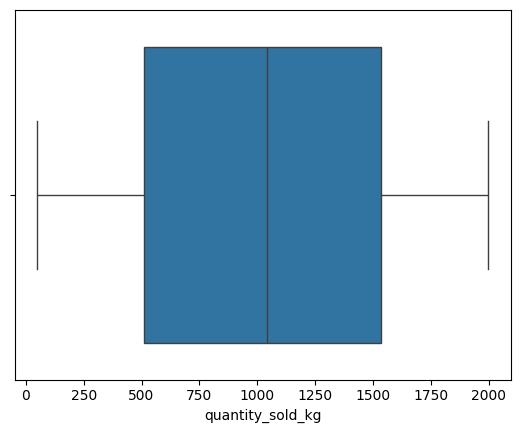

In [31]:
sns.boxplot(x=df['quantity_sold_kg'])
plt.show()

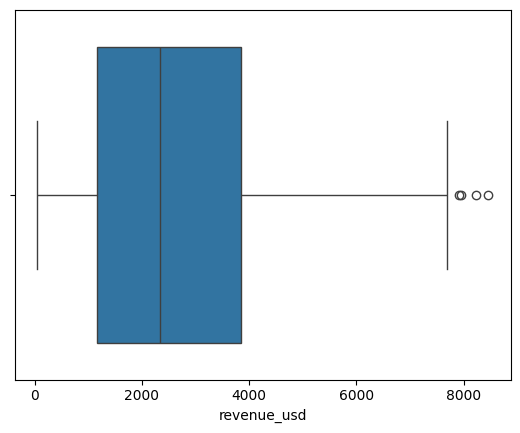

In [32]:
sns.boxplot(x=df['revenue_usd'])
plt.show()

### IQR Method -

In [33]:
# Q1 = df['price_per_kg_usd'].quantile(0.25)
# Q3 = df['price_per_kg_usd'].quantile(0.75)

# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# outliers = df[(df['price_per_kg_usd'] < lower) | (df['price_per_kg_usd'] > upper)]

In [34]:
# len(outliers)

### Histogram Method -

In [35]:
# df['price_per_kg_usd'].hist()
# plt.show()

In [36]:
# df['quantity_sold_kg'].hist()
# plt.show()

In [37]:
# df['revenue_usd'].hist()
# plt.show()

In [38]:
## 10. 

In [39]:
df.shape

(500, 11)

In [40]:
df.head(10)

,record_id,country,apple_variety,quality_grade,market_type,month_name,year,price_per_kg_usd,quantity_sold_kg,revenue_usd,calculated_revenue
0,1,Brazil,Gala,Premium,Supermarket,November,2024,4.31,858,3697.98,3697.98
1,2,Japan,Fuji,Premium,Supermarket,January,2025,2.96,1913,5662.48,5662.48
2,3,Canada,Red Delicious,Standard,Supermarket,March,2025,2.35,542,1273.70,1273.70
3,4,Brazil,Golden Delicious,Economy,Supermarket,August,2025,1.26,507,638.82,638.82
4,5,Germany,Gala,Economy,Wholesale Market,August,2025,2.97,151,448.47,448.47
5,6,Canada,Red Delicious,Standard,Wholesale Market,October,2024,2.35,1157,2718.95,2718.95
6,7,Germany,Honeycrisp,Premium,Supermarket,April,2024,2.95,1358,4006.10,4006.10
7,8,China,Golden Delicious,Economy,Online Store,July,2025,1.02,471,480.42,480.42
8,9,China,Honeycrisp,Standard,Wholesale Market,November,2024,2.52,1941,4891.32,4891.32
9,10,Canada,Red Delicious,Standard,Online Store,July,2024,3.39,549,1861.11,1861.11


# Apple Sales Data Analysis

## Insight 1: Month-wise Apple Sales.

In [41]:
df.groupby('month_name')['quantity_sold_kg'].sum().sort_values(ascending=False)

month_name
October      57254
February     53953
September    50527
May          45178
April        44707
January      42718
August       38572
November     38129
June         38103
March        37320
December     32355
July         31413
Name: quantity_sold_kg, dtype: int64

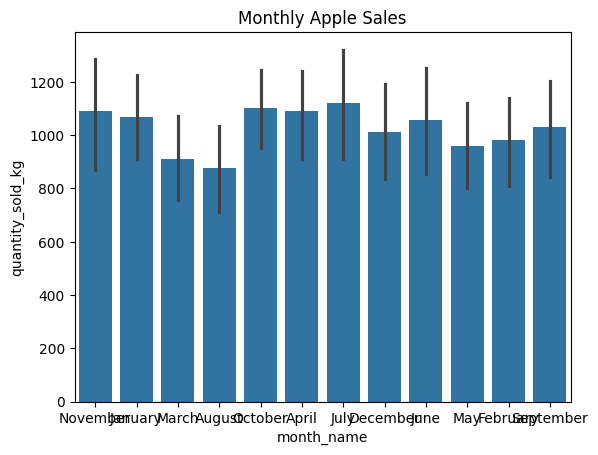

In [80]:
sns.barplot(x='month_name', y='quantity_sold_kg', data=df )
plt.title("Monthly Apple Sales")
plt.savefig("Month-wise Apple Sales.png", dpi=300)
plt.show()

# Different months me apple sales vary karti hain. Is analysis se pata chalta hai ki kaunse months me apple demand highest aur lowest hai.

# 

## Insight 2: Quality-wise Apple Sales

In [43]:
df.groupby('quality_grade')['quantity_sold_kg'].sum().sort_values(ascending=False)

quality_grade
Standard    179153
Economy     165677
Premium     165399
Name: quantity_sold_kg, dtype: int64

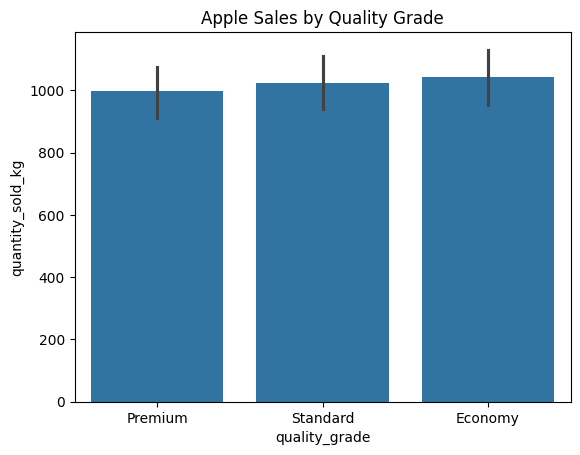

In [88]:
sns.barplot(x='quality_grade', y='quantity_sold_kg', data=df)
plt.title("Apple Sales by Quality Grade")
plt.savefig("Quality-wise Apple Sales.png", dpi=300)
plt.show()

# Ye analysis batata hai ki customers premium, standard ya economy me se kis quality ke apples sabse zyada kharid rahe hain.

## Insight 3: Variety-wise Apple Sales

In [45]:
df.groupby('apple_variety')['quantity_sold_kg'].sum().sort_values(ascending=False)

apple_variety
Fuji                81241
Pink Lady           78318
Honeycrisp          77317
Gala                77080
Granny Smith        74844
Red Delicious       65430
Golden Delicious    55999
Name: quantity_sold_kg, dtype: int64

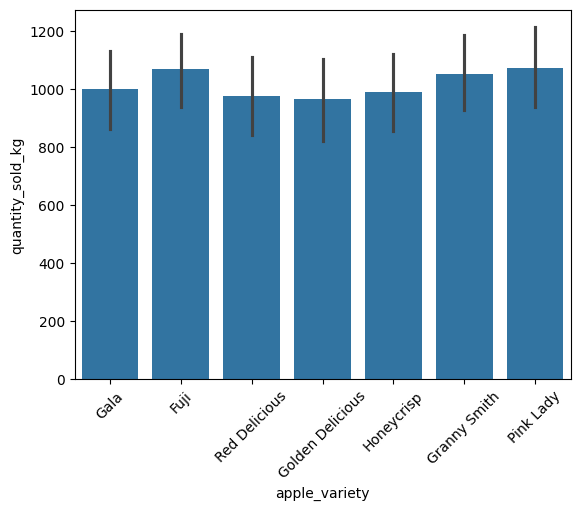

In [82]:
sns.barplot(x='apple_variety', y='quantity_sold_kg', data=df)
plt.xticks(rotation=45)
plt.savefig("Variety-wise Apple Sale.png", dpi=300)
plt.show()

# Isse pata chalta hai ki kaunsi apple variety market me sabse popular hai aur kiski demand kam hai.

## Insight 4: Market-wise Apple Sales

In [47]:
df.groupby('market_type')['quantity_sold_kg'].sum().sort_values(ascending=False)

market_type
Wholesale Market    141762
Supermarket         137178
Local Market        133572
Online Store         97717
Name: quantity_sold_kg, dtype: int64

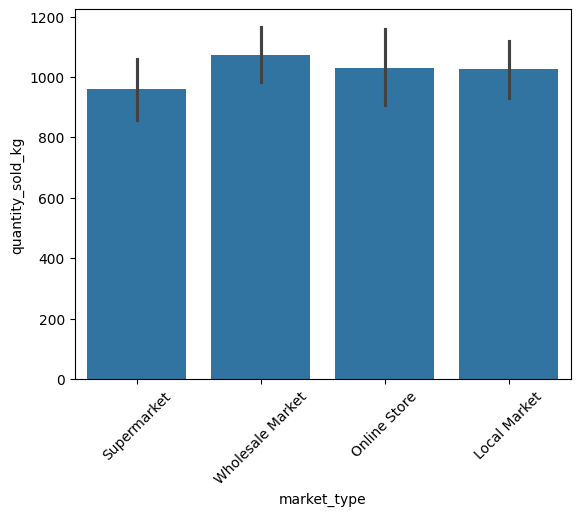

In [83]:
sns.barplot(x='market_type', y='quantity_sold_kg', data=df)
plt.xticks(rotation=45)
plt.savefig("Market-wise Apple Sales.png", dpi=300)
plt.show()

# Ye insight batata hai ki kis market channel (supermarket, online, wholesale, local) me apples sabse zyada sell ho rahe hain.

## Insight 5: Country-wise Apple Demand

In [49]:
df.groupby('country')['quantity_sold_kg'].sum().sort_values(ascending=False)

country
China           53233
UAE             46317
Germany         45602
Brazil          42278
Italy           40431
UK              40339
Saudi Arabia    39308
Australia       36209
India           36144
France          34555
Canada          33883
Japan           32953
USA             28977
Name: quantity_sold_kg, dtype: int64

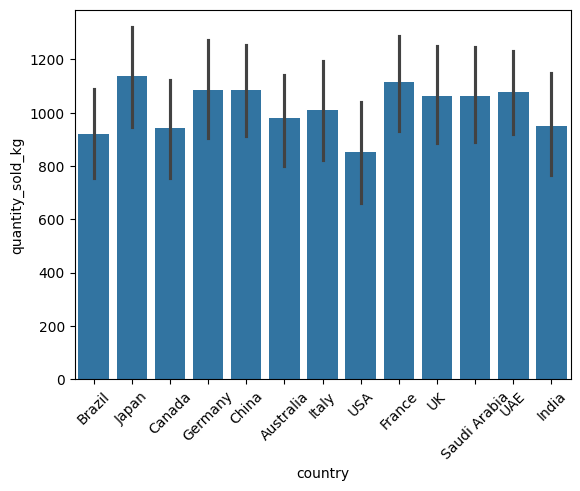

In [84]:
sns.barplot(x='country', y='quantity_sold_kg', data=df)
plt.xticks(rotation=45)
plt.savefig("Country-wise Apple Demand.png", dpi=300)
plt.show()

# Is analysis se pata chalta hai ki kaunsi country apples sabse zyada purchase kar rahi hai.

## Insight 6: Country Ranking by Revenue

In [51]:
df.groupby('country')['revenue_usd'].sum().sort_values(ascending=False)

country
China           149148.82
Germany         124117.08
UAE             110790.44
UK              108821.03
Brazil          103367.48
Saudi Arabia    100835.50
Canada           99437.85
France           99131.38
India            95698.61
Italy            94507.81
Japan            87110.48
USA              79857.97
Australia        78102.00
Name: revenue_usd, dtype: float64

In [52]:
# Ye ranking batati hai ki kaunsi country business ke liye sabse zyada revenue generate kar rahi hai.

## Insight 7: Country vs Apple Variety

In [53]:
pd.pivot_table(
    df,
    values='quantity_sold_kg',
    index='country',
    columns='apple_variety',
    aggfunc='sum'
)

apple_variety,Fuji,Gala,Golden Delicious,Granny Smith,Honeycrisp,Pink Lady,Red Delicious
country,,,,,,,
Australia,8144.0,3266.0,3787.0,3942.0,2553.0,10074.0,4443.0
Brazil,5586.0,12096.0,5691.0,5488.0,2330.0,5992.0,5095.0
Canada,8936.0,3473.0,2450.0,NaN,4625.0,7714.0,6685.0
China,7152.0,11350.0,5909.0,8307.0,11198.0,2534.0,6783.0
France,5048.0,4647.0,5597.0,4218.0,4011.0,4753.0,6281.0
Germany,9335.0,11451.0,1143.0,8351.0,7227.0,5389.0,2706.0
India,3379.0,3311.0,7278.0,5377.0,2835.0,4193.0,9771.0
Italy,2135.0,6198.0,4072.0,6779.0,9875.0,7015.0,4357.0
Japan,9589.0,2614.0,2596.0,4086.0,6770.0,4041.0,3257.0


In [54]:
# Is analysis se pata chalta hai ki har country kis apple variety ko zyada prefer karti hai.

## Insight 9: Year-wise Revenue Comparison

In [55]:
df.groupby('year')['revenue_usd'].sum()

year
2024    655125.65
2025    675800.80
Name: revenue_usd, dtype: float64

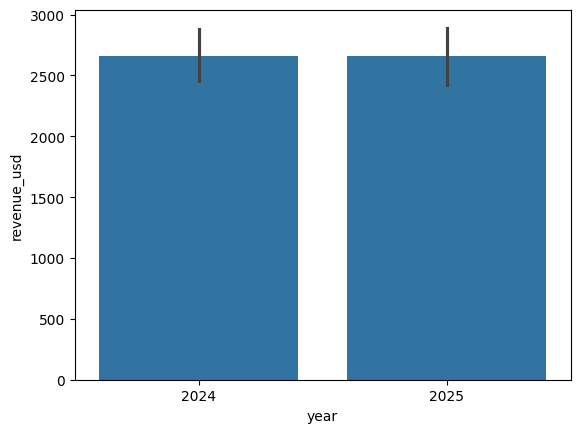

In [85]:
sns.barplot(x='year', y='revenue_usd', data=df)
plt.savefig("Year-wise Revenue Comparison.png", dpi=300)
plt.show()

# Is comparison se pata chalta hai ki 2024 aur 2025 me se kis year me apple business ne zyada revenue generate kiya.

## Insight 10: Month Ranking by Revenue

In [57]:
df.groupby('month_name')['revenue_usd'].sum().sort_values(ascending=False)

month_name
October      142502.19
February     138061.33
September    137378.32
April        120236.41
January      119097.93
May          111365.15
March        107457.94
November     101023.53
August        97792.90
June          88030.97
December      86722.23
July          81257.55
Name: revenue_usd, dtype: float64

In [58]:
# Ye ranking batati hai ki kaunse months apple business ke liye sabse profitable hain.

## Insight 11: Country Ranking by Revenue

In [59]:
df.groupby('country')['revenue_usd'].sum().sort_values(ascending=False)

country
China           149148.82
Germany         124117.08
UAE             110790.44
UK              108821.03
Brazil          103367.48
Saudi Arabia    100835.50
Canada           99437.85
France           99131.38
India            95698.61
Italy            94507.81
Japan            87110.48
USA              79857.97
Australia        78102.00
Name: revenue_usd, dtype: float64

In [60]:
# Isse pata chalta hai ki kaunsi country apple sales se highest revenue generate kar rahi hai.

## Extra Insight 1: Most Expensive Apple Variety

In [61]:
df.groupby('apple_variety')['price_per_kg_usd'].mean().sort_values(ascending=False)

apple_variety
Gala                2.874675
Pink Lady           2.774384
Red Delicious       2.745522
Granny Smith        2.627606
Golden Delicious    2.619138
Fuji                2.538947
Honeycrisp          2.537949
Name: price_per_kg_usd, dtype: float64

In [62]:
# Is analysis se pata chalta hai ki kaunsi apple variety average me sabse mehngi hai.

## Extra Insight 2: Quantity vs Revenue Relationship

In [63]:
df[['quantity_sold_kg','revenue_usd']].corr()

,quantity_sold_kg,revenue_usd
quantity_sold_kg,1.000000,0.749166
revenue_usd,0.749166,1.000000


In [64]:
# Ye correlation analysis batata hai ki revenue quantity se zyada influence hota hai ya price se.

## Extra Insight 3: Market vs Revenue

In [65]:
df.groupby('market_type')['revenue_usd'].sum().sort_values(ascending=False)

market_type
Supermarket         366894.89
Wholesale Market    358324.63
Local Market        350371.06
Online Store        255335.87
Name: revenue_usd, dtype: float64

In [66]:
# Ye insight batata hai ki kaunsa market channel company ke liye sabse zyada revenue generate karta hai.

## Extra Insight 4: Price Distribution

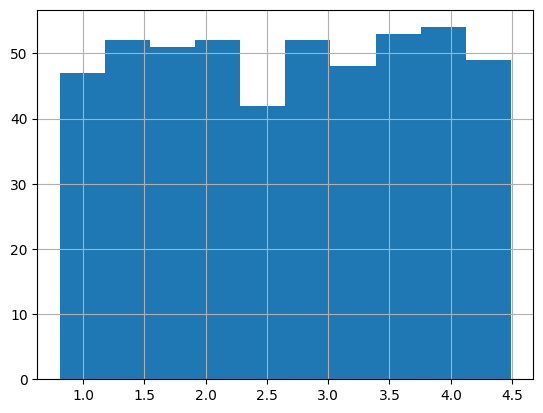

In [86]:
df['price_per_kg_usd'].hist()
plt.savefig("Price Distribution.png", dpi=300)

In [68]:
# Ye distribution chart batata hai ki apple prices kis range me zyada frequently occur kar rahe hain.

In [74]:
df.head(10)

,record_id,country,apple_variety,quality_grade,market_type,month_name,year,price_per_kg_usd,quantity_sold_kg,revenue_usd,calculated_revenue
0,1,Brazil,Gala,Premium,Supermarket,November,2024,4.31,858,3697.98,3697.98
1,2,Japan,Fuji,Premium,Supermarket,January,2025,2.96,1913,5662.48,5662.48
2,3,Canada,Red Delicious,Standard,Supermarket,March,2025,2.35,542,1273.70,1273.70
3,4,Brazil,Golden Delicious,Economy,Supermarket,August,2025,1.26,507,638.82,638.82
4,5,Germany,Gala,Economy,Wholesale Market,August,2025,2.97,151,448.47,448.47
5,6,Canada,Red Delicious,Standard,Wholesale Market,October,2024,2.35,1157,2718.95,2718.95
6,7,Germany,Honeycrisp,Premium,Supermarket,April,2024,2.95,1358,4006.10,4006.10
7,8,China,Golden Delicious,Economy,Online Store,July,2025,1.02,471,480.42,480.42
8,9,China,Honeycrisp,Standard,Wholesale Market,November,2024,2.52,1941,4891.32,4891.32
9,10,Canada,Red Delicious,Standard,Online Store,July,2024,3.39,549,1861.11,1861.11


In [70]:
df.shape

(500, 11)

In [89]:
df.to_csv('apple_sales_cleaned_dataset.csv' , index=False)

In [90]:
import os
os.getcwd()

'C:\\Users\\MY PC'